# E-commerce Customer Analytics and Sales Forecasting
## Notebook 03 — Feature Engineering

### Overview

Feature engineering is one of the most important stages of the machine learning pipeline.

In this notebook, I transform the raw datasets into structured features suitable for machine learning models.

These engineered features support two key modeling tasks:

- Customer Segmentation
- Sales Forecasting

---

### Objectives

The objectives of this notebook are:

1. Create customer-level behavioral features
2. Construct RFM metrics
3. Generate temporal features for time-series forecasting
4. Build lag and rolling window features
5. Validate feature distributions and correlations
6. Export a structured feature store

---

### Feature Categories

The engineered features fall into three categories.

**Customer behavioral features**

- RFM metrics
- purchase rate
- engagement indicators

**Time-series features**

- temporal encodings
- lag variables
- rolling window statistics

**Derived analytical features**

- average spend per order
- customer tenure
- engagement index

In [1]:
"""
Environment Setup
"""

import os
import pandas as pd
from pandas.plotting import autocorrelation_plot
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

DATA_PATH = "../data/processed"
FIG_PATH = "../figures/feature_engineering"

os.makedirs(FIG_PATH, exist_ok=True)

print("Environment initialized.")

Environment initialized.


In [2]:
"""
Load Processed Datasets
"""

customers = pd.read_csv(
    f"{DATA_PATH}/customers.csv",
    parse_dates=["signup_date"]
)

orders = pd.read_csv(
    f"{DATA_PATH}/orders.csv",
    parse_dates=["order_date"]
)

print("Customers:", customers.shape)
print("Orders:", orders.shape)

customers.head()

Customers: (10000, 15)
Orders: (495949, 8)


/var/folders/hr/kl__grj55kd6q86n_ksznz3r0000gn/T/ipykernel_22229/3259695677.py:10: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  orders = pd.read_csv(


,customer_id,signup_date,age,income,country,loyalty_member,website_visits,app_usage,discount_usage,engagement_score,purchase_propensity,total_orders,total_spent,average_order_value,days_since_last_purchase
0,6173,2023-01-01,38,70953,Portugal,True,8,4,False,0.206216,0.369702,47.0,4547.73,96.760213,7.0
1,7128,2023-01-03,21,42602,Spain,True,11,4,True,0.438138,0.493732,68.0,5440.13,80.001912,10.0
2,4220,2023-01-03,40,30478,France,False,12,2,True,0.546699,0.320223,40.0,3978.12,99.453000,4.0
3,1120,2023-01-04,52,22415,Portugal,True,13,1,True,0.562599,0.575448,118.0,11282.80,95.616949,2.0
4,2020,2023-01-05,51,39682,Italy,False,9,4,False,0.254583,0.136320,17.0,2259.21,132.894706,1.0


In [3]:
"""
Plot Utility
"""

def save_plot(name):
    
    path = os.path.join(FIG_PATH, name)
    
    plt.tight_layout()
    plt.savefig(path, dpi=300)
    plt.show()

## Feature Validation

Before engineering new features, I validate the input datasets.

Data validation ensures that:

- datasets contain no unexpected missing values
- numerical features fall within reasonable ranges
- distributions appear consistent with expectations

Performing these checks early helps prevent issues later in the machine learning pipeline.

In this section, I inspect:

- missing values
- feature distributions
- summary statistics

In [4]:
"""
Missing Value Validation
"""

print("Missing values in customers dataset:")
print(customers.isna().sum())

print("\nMissing values in orders dataset:")
print(orders.isna().sum())

Missing values in customers dataset:
customer_id                 0
signup_date                 0
age                         0
income                      0
country                     0
loyalty_member              0
website_visits              0
app_usage                   0
discount_usage              0
engagement_score            0
purchase_propensity         0
total_orders                0
total_spent                 0
average_order_value         0
days_since_last_purchase    0
dtype: int64

Missing values in orders dataset:
order_id                   0
customer_id                0
order_date                 0
promotion                  0
holiday               450933
product_category           0
order_value                0
marketing_campaign         0
dtype: int64


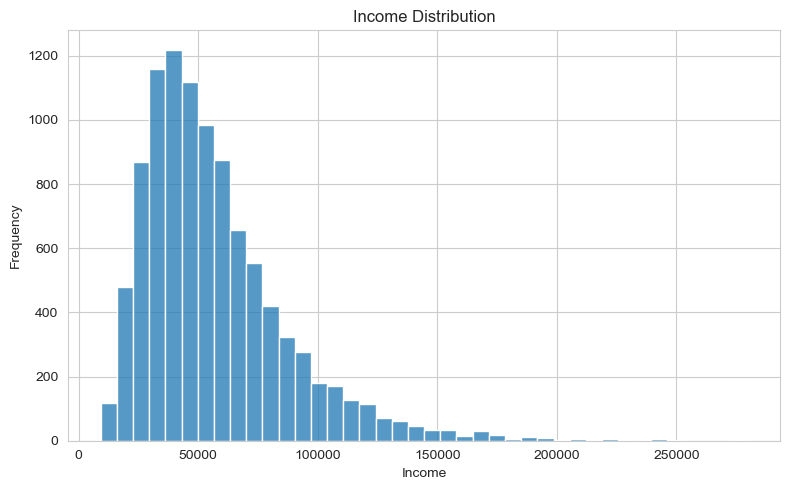

In [5]:
"""
Key Feature Distributions
"""

plt.figure(figsize=(8,5))

sns.histplot(customers["income"], bins=40)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")

save_plot("income_distribution_feature_validation.png")

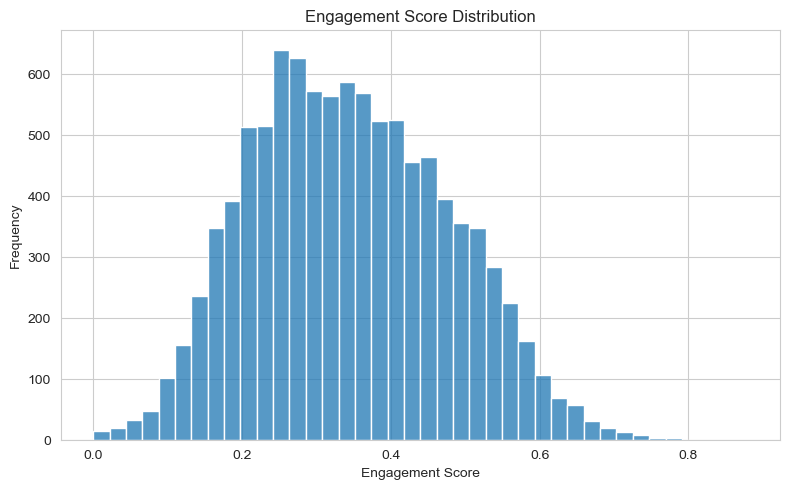

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(customers["engagement_score"], bins=40)

plt.title("Engagement Score Distribution")
plt.xlabel("Engagement Score")
plt.ylabel("Frequency")

save_plot("engagement_score_distribution.png")

In [7]:
"""
Feature Summary Statistics
"""

customers.describe()

,customer_id,signup_date,age,income,website_visits,app_usage,engagement_score,purchase_propensity,total_orders,total_spent,average_order_value,days_since_last_purchase
count,10000.00000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,2023-07-27 17:21:33.120000,34.774700,56845.327000,8.027800,4.026400,0.345767,0.311546,49.594900,5144.643333,103.840085,10.88820
min,1.00000,2023-01-01 00:00:00,18.000000,9204.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,2023-04-29 18:00:00,28.000000,35655.000000,6.000000,3.000000,0.245839,0.171078,28.000000,2844.885000,90.326061,1.00000
50%,5000.50000,2023-07-14 00:00:00,35.000000,50069.000000,8.000000,4.000000,0.338667,0.324097,50.000000,4968.120000,101.894076,4.00000
75%,7500.25000,2023-10-11 00:00:00,41.000000,70356.500000,10.000000,5.000000,0.442566,0.402140,66.000000,6943.980000,114.754808,9.00000
max,10000.00000,2024-09-02 00:00:00,69.000000,279775.000000,23.000000,13.000000,0.879219,0.807512,138.000000,16658.370000,560.390000,730.00000
std,2886.89568,NaN,9.565097,30428.109126,2.828008,1.995069,0.132753,0.153235,25.335244,2765.850325,22.075021,28.31523


## RFM Feature Engineering

RFM analysis is a standard method used in customer analytics.

It captures three key dimensions of customer purchasing behavior:

### Recency

How recently the customer made a purchase.

Customers who purchased recently are more likely to purchase again.

### Frequency

How often the customer makes purchases.

Frequent buyers typically represent higher-value customers.

### Monetary Value

How much the customer has spent in total.

Customers with higher spending contribute more revenue.

These three variables form the basis for many customer segmentation models.

In [8]:
"""
Recency Feature
"""

reference_date = orders["order_date"].max()

recency = (
    orders
    .groupby("customer_id")["order_date"]
    .max()
    .reset_index()
)

recency["recency_days"] = (
    reference_date - recency["order_date"]
).dt.days

recency = recency[["customer_id","recency_days"]]

recency.head()

,customer_id,recency_days
0,1,2
1,2,6
2,3,2
3,4,11
4,5,7


In [9]:
"""
Frequency Feature
"""

frequency = (
    orders
    .groupby("customer_id")
    .size()
    .reset_index(name="frequency")
)

frequency.head()

,customer_id,frequency
0,1,51
1,2,76
2,3,16
3,4,21
4,5,53


In [10]:
"""
Monetary Feature
"""

monetary = (
    orders
    .groupby("customer_id")["order_value"]
    .sum()
    .reset_index(name="monetary")
)

monetary.head()

,customer_id,monetary
0,1,5027.08
1,2,8823.78
2,3,2029.18
3,4,1941.90
4,5,6056.00


In [11]:
"""
Construct RFM Dataset
"""

rfm = recency.merge(
    frequency,
    on="customer_id"
)

rfm = rfm.merge(
    monetary,
    on="customer_id"
)

rfm.head()

,customer_id,recency_days,frequency,monetary
0,1,2,51,5027.08
1,2,6,76,8823.78
2,3,2,16,2029.18
3,4,11,21,1941.90
4,5,7,53,6056.00


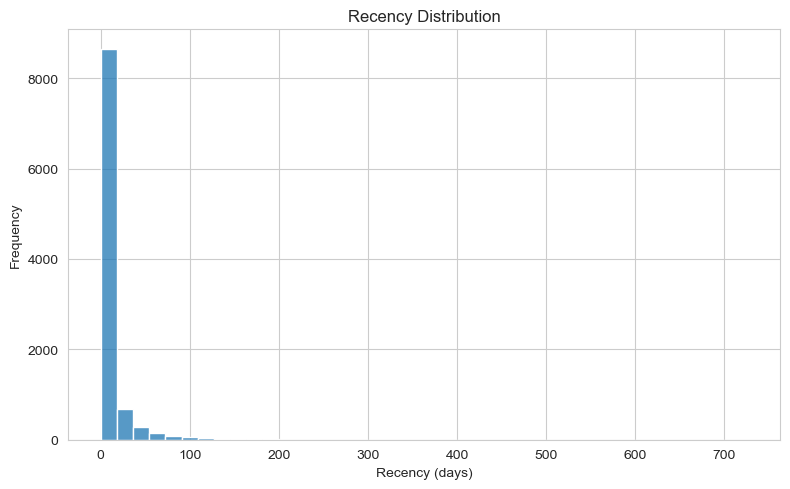

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(rfm["recency_days"], bins=40)

plt.title("Recency Distribution")
plt.xlabel("Recency (days)")
plt.ylabel("Frequency")

save_plot("rfm_recency_distribution.png")

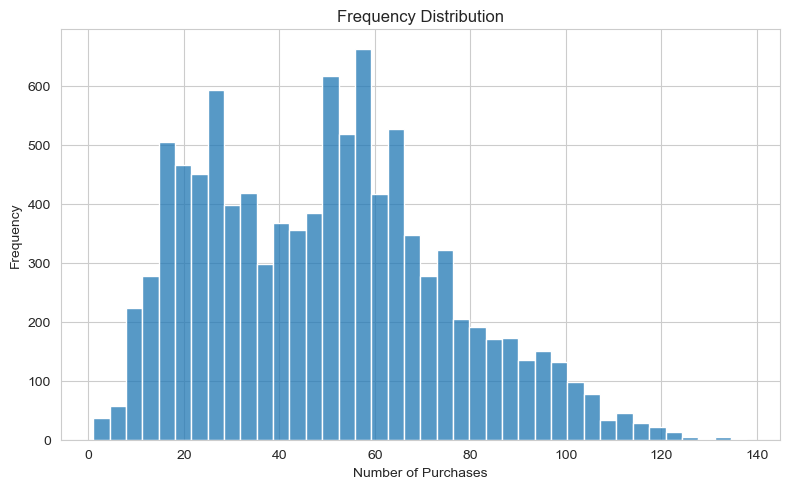

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(rfm["frequency"], bins=40)

plt.title("Frequency Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Frequency")

save_plot("rfm_frequency_distribution.png")

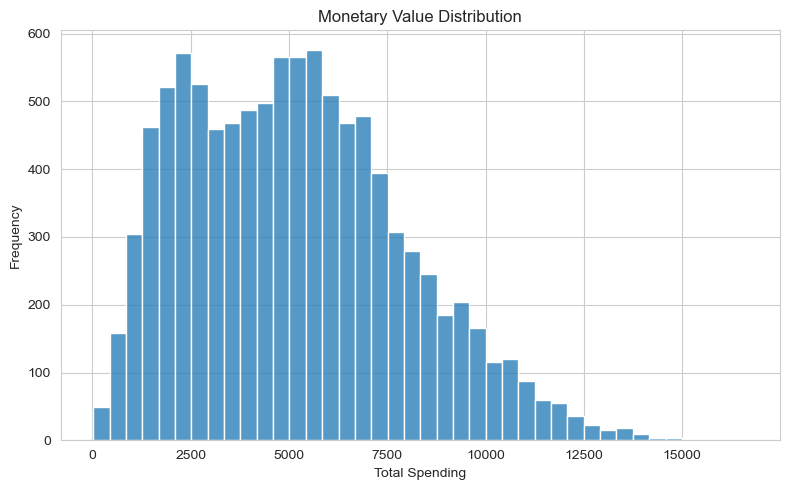

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(rfm["monetary"], bins=40)

plt.title("Monetary Value Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Frequency")

save_plot("rfm_monetary_distribution.png")

## RFM Scoring

After computing the raw RFM metrics, I convert them into standardized scores.

Each variable is divided into quantiles to create scores between 1 and 5.

### Scoring Logic

**Recency**

- More recent purchases → higher score

**Frequency**

- Higher purchase frequency → higher score

**Monetary**

- Higher spending → higher score

### Customer Segments

RFM scores allow me to create interpretable customer segments such as:

- Champions
- Loyal Customers
- Potential Loyalists
- At Risk
- Lost Customers

These segments are widely used in marketing and CRM systems.

In [15]:
"""
Recency Score
"""

rfm["recency_score"] = pd.qcut(
    rfm["recency_days"],
    5,
    labels=[5,4,3,2,1],
    duplicates="drop"
)

rfm.head()

,customer_id,recency_days,frequency,monetary,recency_score
0,1,2,51,5027.08,4
1,2,6,76,8823.78,2
2,3,2,16,2029.18,4
3,4,11,21,1941.90,2
4,5,7,53,6056.00,2


In [16]:
"""
Frequency Score
"""

rfm["frequency_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    5,
    labels=[1,2,3,4,5],
    duplicates="drop"
)

rfm.head()

,customer_id,recency_days,frequency,monetary,recency_score,frequency_score
0,1,2,51,5027.08,4,3
1,2,6,76,8823.78,2,5
2,3,2,16,2029.18,4,1
3,4,11,21,1941.90,2,1
4,5,7,53,6056.00,2,3


In [17]:
"""
Monetary Score
"""

rfm["monetary_score"] = pd.qcut(
    rfm["monetary"],
    5,
    labels=[1,2,3,4,5],
    duplicates="drop"
)

rfm.head()

,customer_id,recency_days,frequency,monetary,recency_score,frequency_score,monetary_score
0,1,2,51,5027.08,4,3,3
1,2,6,76,8823.78,2,5,5
2,3,2,16,2029.18,4,1,1
3,4,11,21,1941.90,2,1,1
4,5,7,53,6056.00,2,3,4


In [18]:
"""
RFM Score
"""

rfm["rfm_score"] = (
    rfm["recency_score"].astype(str) +
    rfm["frequency_score"].astype(str) +
    rfm["monetary_score"].astype(str)
)

rfm.head()

,customer_id,recency_days,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_score
0,1,2,51,5027.08,4,3,3,433
1,2,6,76,8823.78,2,5,5,255
2,3,2,16,2029.18,4,1,1,411
3,4,11,21,1941.90,2,1,1,211
4,5,7,53,6056.00,2,3,4,234


In [19]:
"""
Customer Segment Labels
"""

rfm["customer_segment"] = "Other"

rfm.loc[
    (rfm["recency_score"] >= 4) &
    (rfm["frequency_score"] >= 4),
    "customer_segment"
] = "Champions"

rfm.loc[
    (rfm["frequency_score"] >= 4),
    "customer_segment"
] = "Loyal Customers"

rfm.loc[
    (rfm["recency_score"] <= 2),
    "customer_segment"
] = "At Risk"

rfm.head()

,customer_id,recency_days,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_score,customer_segment
0,1,2,51,5027.08,4,3,3,433,At Risk
1,2,6,76,8823.78,2,5,5,255,At Risk
2,3,2,16,2029.18,4,1,1,411,At Risk
3,4,11,21,1941.90,2,1,1,211,At Risk
4,5,7,53,6056.00,2,3,4,234,At Risk


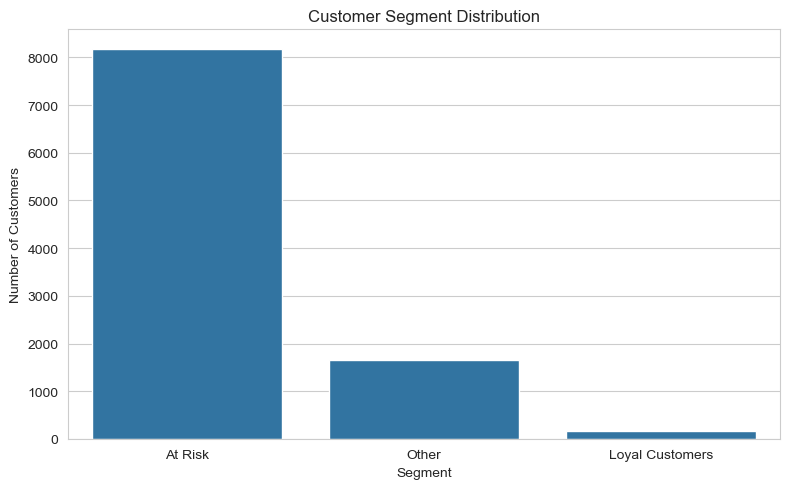

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=rfm,
    x="customer_segment",
    order=rfm["customer_segment"].value_counts().index
)

plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

save_plot("rfm_customer_segments_distribution.png")

## Customer Behavioral Features

Beyond RFM metrics, I derive additional behavioral indicators that capture how customers interact with the platform.

These features provide deeper insight into customer activity patterns and improve the performance of segmentation models.

In this section, I construct several behavioral features.

### Customer Tenure

The number of days since the customer joined the platform.

### Average Spend per Order

The average amount spent per transaction.

### Purchase Rate

The frequency of purchases relative to the customer's tenure.

### Engagement Index

A composite metric that summarizes platform engagement based on website visits, app usage, and engagement signals.

In [21]:
"""
Customer Tenure Feature
"""

reference_date = orders["order_date"].max()

customers["customer_tenure_days"] = (
    reference_date - customers["signup_date"]
).dt.days

customers[["customer_id","customer_tenure_days"]].head()

,customer_id,customer_tenure_days
0,6173,730
1,7128,728
2,4220,728
3,1120,727
4,2020,726


In [22]:
"""
Average Spend per Order
"""

rfm["avg_spend_per_order"] = (
    rfm["monetary"] / rfm["frequency"]
)

rfm.head()

,customer_id,recency_days,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_score,customer_segment,avg_spend_per_order
0,1,2,51,5027.08,4,3,3,433,At Risk,98.570196
1,2,6,76,8823.78,2,5,5,255,At Risk,116.102368
2,3,2,16,2029.18,4,1,1,411,At Risk,126.823750
3,4,11,21,1941.90,2,1,1,211,At Risk,92.471429
4,5,7,53,6056.00,2,3,4,234,At Risk,114.264151


In [23]:
"""
Purchase Rate
"""

rfm = rfm.merge(
    customers[["customer_id","customer_tenure_days"]],
    on="customer_id",
    how="left"
)

rfm["purchase_rate"] = (
    rfm["frequency"] /
    (rfm["customer_tenure_days"] + 1)
)

rfm.head()

,customer_id,recency_days,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_score,customer_segment,avg_spend_per_order,customer_tenure_days,purchase_rate
0,1,2,51,5027.08,4,3,3,433,At Risk,98.570196,472,0.107822
1,2,6,76,8823.78,2,5,5,255,At Risk,116.102368,549,0.138182
2,3,2,16,2029.18,4,1,1,411,At Risk,126.823750,427,0.037383
3,4,11,21,1941.90,2,1,1,211,At Risk,92.471429,614,0.034146
4,5,7,53,6056.00,2,3,4,234,At Risk,114.264151,329,0.160606


In [24]:
"""
Improved Engagement Index
"""

customers["engagement_index"] = (
    0.4 * customers["website_visits"] +
    0.3 * customers["app_usage"] +
    0.3 * customers["engagement_score"]
)

customers[[
    "customer_id",
    "website_visits",
    "app_usage",
    "engagement_score",
    "engagement_index"
]].head()

,customer_id,website_visits,app_usage,engagement_score,engagement_index
0,6173,8,4,0.206216,4.461865
1,7128,11,4,0.438138,5.731441
2,4220,12,2,0.546699,5.564010
3,1120,13,1,0.562599,5.668780
4,2020,9,4,0.254583,4.876375


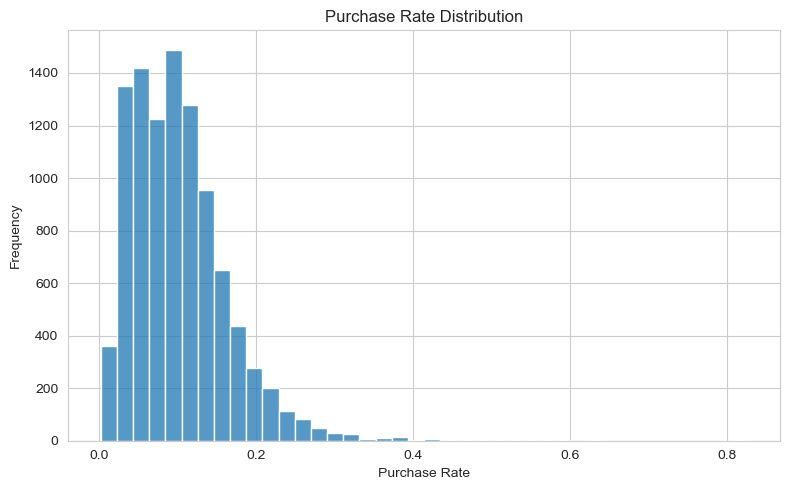

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(rfm["purchase_rate"], bins=40)

plt.title("Purchase Rate Distribution")
plt.xlabel("Purchase Rate")
plt.ylabel("Frequency")

save_plot("purchase_rate_distribution.png")

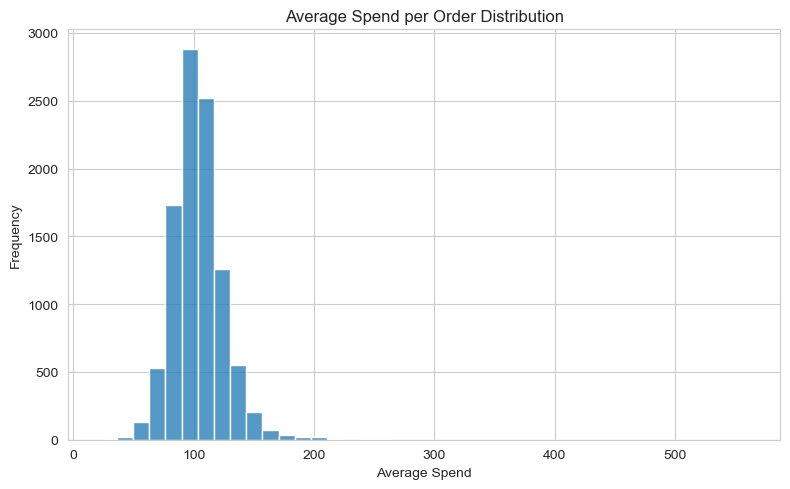

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(rfm["avg_spend_per_order"], bins=40)

plt.title("Average Spend per Order Distribution")
plt.xlabel("Average Spend")
plt.ylabel("Frequency")

save_plot("avg_spend_per_order_distribution.png")

## Time-Series Feature Engineering

For sales forecasting models, I structure the transaction data into a time-series format.

Instead of individual transactions, forecasting models typically operate on aggregated time intervals such as:

- daily sales
- weekly demand
- monthly revenue

In this section, I construct a daily time-series dataset that summarizes platform activity.

The dataset includes:

### Daily Metrics

- daily revenue
- number of orders

### Temporal Features

- year
- month
- day of week
- week of year

### Cyclical Encodings

Temporal variables such as month and weekday follow cyclical patterns.  
To capture this behavior, I use sine and cosine transformations.

In [27]:
"""
Daily Sales Dataset
"""

daily_sales = (
    orders
    .groupby("order_date")
    .agg(
        daily_revenue=("order_value","sum"),
        daily_orders=("order_id","count")
    )
    .reset_index()
)

daily_sales.head()

,order_date,daily_revenue,daily_orders
0,2023-01-01,66253.81,613
1,2023-01-02,54665.55,504
2,2023-01-03,59619.06,535
3,2023-01-04,51748.44,482
4,2023-01-05,49735.05,468


In [28]:
"""
Basic Time Features
"""

daily_sales["year"] = daily_sales["order_date"].dt.year
daily_sales["month"] = daily_sales["order_date"].dt.month
daily_sales["day"] = daily_sales["order_date"].dt.day
daily_sales["day_of_week"] = daily_sales["order_date"].dt.dayofweek
daily_sales["week_of_year"] = daily_sales["order_date"].dt.isocalendar().week.astype(int)

daily_sales["is_weekend"] = (
    daily_sales["day_of_week"].isin([5,6]).astype(int)
)

daily_sales.head()

,order_date,daily_revenue,daily_orders,year,month,day,day_of_week,week_of_year,is_weekend
0,2023-01-01,66253.81,613,2023,1,1,6,52,1
1,2023-01-02,54665.55,504,2023,1,2,0,1,0
2,2023-01-03,59619.06,535,2023,1,3,1,1,0
3,2023-01-04,51748.44,482,2023,1,4,2,1,0
4,2023-01-05,49735.05,468,2023,1,5,3,1,0


In [29]:
"""
Cyclical Encoding
"""

daily_sales["month_sin"] = np.sin(
    2 * np.pi * daily_sales["month"] / 12
)

daily_sales["month_cos"] = np.cos(
    2 * np.pi * daily_sales["month"] / 12
)

daily_sales["weekday_sin"] = np.sin(
    2 * np.pi * daily_sales["day_of_week"] / 7
)

daily_sales["weekday_cos"] = np.cos(
    2 * np.pi * daily_sales["day_of_week"] / 7
)

daily_sales.head()

,order_date,daily_revenue,daily_orders,year,month,day,day_of_week,week_of_year,is_weekend,month_sin,month_cos,weekday_sin,weekday_cos
0,2023-01-01,66253.81,613,2023,1,1,6,52,1,0.5,0.866025,-0.781831,0.623490
1,2023-01-02,54665.55,504,2023,1,2,0,1,0,0.5,0.866025,0.000000,1.000000
2,2023-01-03,59619.06,535,2023,1,3,1,1,0,0.5,0.866025,0.781831,0.623490
3,2023-01-04,51748.44,482,2023,1,4,2,1,0,0.5,0.866025,0.974928,-0.222521
4,2023-01-05,49735.05,468,2023,1,5,3,1,0,0.5,0.866025,0.433884,-0.900969


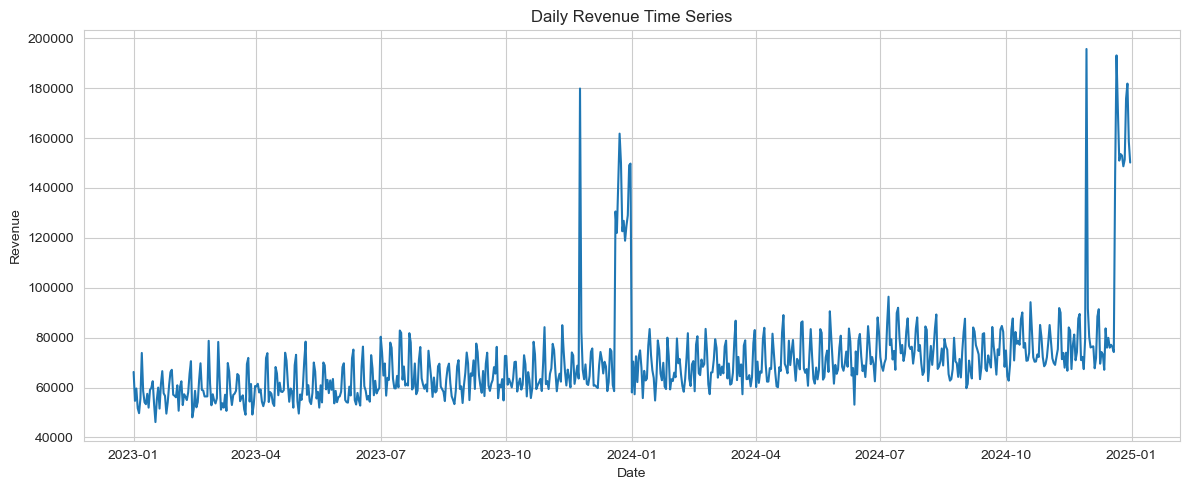

In [30]:
plt.figure(figsize=(12,5))

sns.lineplot(
    x=daily_sales["order_date"],
    y=daily_sales["daily_revenue"]
)

plt.title("Daily Revenue Time Series")
plt.xlabel("Date")
plt.ylabel("Revenue")

save_plot("daily_revenue_timeseries.png")

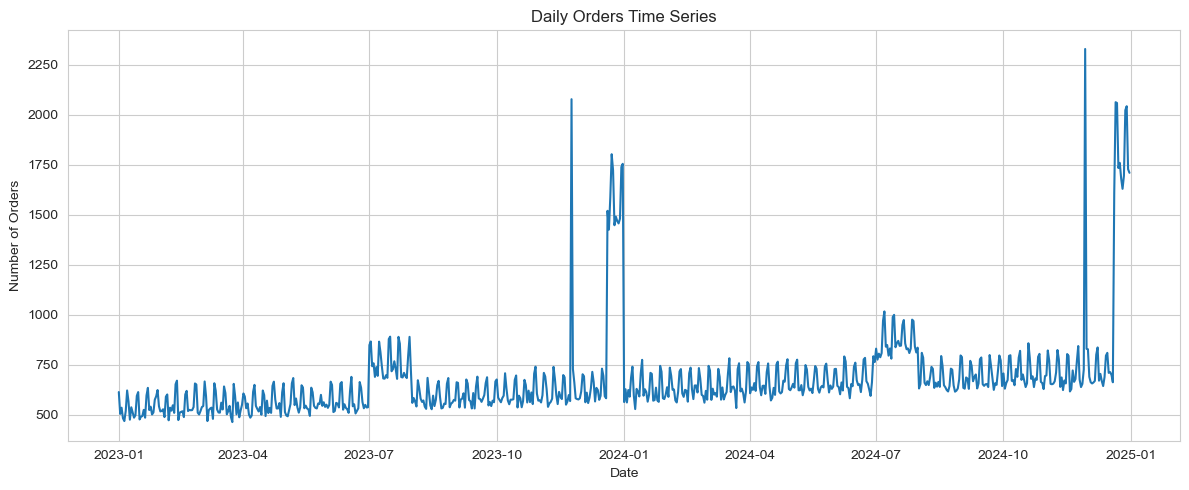

In [31]:
plt.figure(figsize=(12,5))

sns.lineplot(
    x=daily_sales["order_date"],
    y=daily_sales["daily_orders"]
)

plt.title("Daily Orders Time Series")
plt.xlabel("Date")
plt.ylabel("Number of Orders")

save_plot("daily_orders_timeseries.png")

## Lag Feature Engineering

Lag features are essential in time-series forecasting models.

They represent past values of a variable and allow the model to learn temporal dependencies.

For example:

- `lag_1` → value from the previous day  
- `lag_7` → value from the previous week  
- `lag_30` → value from the previous month  

These features help models capture:

- short-term dependencies
- weekly seasonality
- longer-term trends

In this section, I create lag features for both revenue and order volume.

In [32]:
"""
Revenue Lag Features
"""

lag_days = [1, 7, 14, 30]

for lag in lag_days:
    
    daily_sales[f"revenue_lag_{lag}"] = (
        daily_sales["daily_revenue"]
        .shift(lag)
    )

daily_sales.head(20)

,order_date,daily_revenue,daily_orders,year,month,day,day_of_week,week_of_year,is_weekend,month_sin,month_cos,weekday_sin,weekday_cos,revenue_lag_1,revenue_lag_7,revenue_lag_14,revenue_lag_30
0,2023-01-01,66253.81,613,2023,1,1,6,52,1,0.5,0.866025,-0.781831,0.623490,NaN,NaN,NaN,NaN
1,2023-01-02,54665.55,504,2023,1,2,0,1,0,0.5,0.866025,0.000000,1.000000,66253.81,NaN,NaN,NaN
2,2023-01-03,59619.06,535,2023,1,3,1,1,0,0.5,0.866025,0.781831,0.623490,54665.55,NaN,NaN,NaN
3,2023-01-04,51748.44,482,2023,1,4,2,1,0,0.5,0.866025,0.974928,-0.222521,59619.06,NaN,NaN,NaN
4,2023-01-05,49735.05,468,2023,1,5,3,1,0,0.5,0.866025,0.433884,-0.900969,51748.44,NaN,NaN,NaN
5,2023-01-06,55661.22,518,2023,1,6,4,1,0,0.5,0.866025,-0.433884,-0.900969,49735.05,NaN,NaN,NaN
6,2023-01-07,73869.22,621,2023,1,7,5,1,1,0.5,0.866025,-0.974928,-0.222521,55661.22,NaN,NaN,NaN
7,2023-01-08,58601.95,566,2023,1,8,6,1,1,0.5,0.866025,-0.781831,0.623490,73869.22,66253.81,NaN,NaN
8,2023-01-09,54136.72,475,2023,1,9,0,2,0,0.5,0.866025,0.000000,1.000000,58601.95,54665.55,NaN,NaN
9,2023-01-10,53332.30,537,2023,1,10,1,2,0,0.5,0.866025,0.781831,0.623490,54136.72,59619.06,NaN,NaN


In [33]:
"""
Orders Lag Features
"""

for lag in lag_days:
    
    daily_sales[f"orders_lag_{lag}"] = (
        daily_sales["daily_orders"]
        .shift(lag)
    )

daily_sales.head(20)

,order_date,daily_revenue,daily_orders,year,month,day,day_of_week,week_of_year,is_weekend,month_sin,month_cos,weekday_sin,weekday_cos,revenue_lag_1,revenue_lag_7,revenue_lag_14,revenue_lag_30,orders_lag_1,orders_lag_7,orders_lag_14,orders_lag_30
0,2023-01-01,66253.81,613,2023,1,1,6,52,1,0.5,0.866025,-0.781831,0.623490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-02,54665.55,504,2023,1,2,0,1,0,0.5,0.866025,0.000000,1.000000,66253.81,NaN,NaN,NaN,613.0,NaN,NaN,NaN
2,2023-01-03,59619.06,535,2023,1,3,1,1,0,0.5,0.866025,0.781831,0.623490,54665.55,NaN,NaN,NaN,504.0,NaN,NaN,NaN
3,2023-01-04,51748.44,482,2023,1,4,2,1,0,0.5,0.866025,0.974928,-0.222521,59619.06,NaN,NaN,NaN,535.0,NaN,NaN,NaN
4,2023-01-05,49735.05,468,2023,1,5,3,1,0,0.5,0.866025,0.433884,-0.900969,51748.44,NaN,NaN,NaN,482.0,NaN,NaN,NaN
5,2023-01-06,55661.22,518,2023,1,6,4,1,0,0.5,0.866025,-0.433884,-0.900969,49735.05,NaN,NaN,NaN,468.0,NaN,NaN,NaN
6,2023-01-07,73869.22,621,2023,1,7,5,1,1,0.5,0.866025,-0.974928,-0.222521,55661.22,NaN,NaN,NaN,518.0,NaN,NaN,NaN
7,2023-01-08,58601.95,566,2023,1,8,6,1,1,0.5,0.866025,-0.781831,0.623490,73869.22,66253.81,NaN,NaN,621.0,613.0,NaN,NaN
8,2023-01-09,54136.72,475,2023,1,9,0,2,0,0.5,0.866025,0.000000,1.000000,58601.95,54665.55,NaN,NaN,566.0,504.0,NaN,NaN
9,2023-01-10,53332.30,537,2023,1,10,1,2,0,0.5,0.866025,0.781831,0.623490,54136.72,59619.06,NaN,NaN,475.0,535.0,NaN,NaN


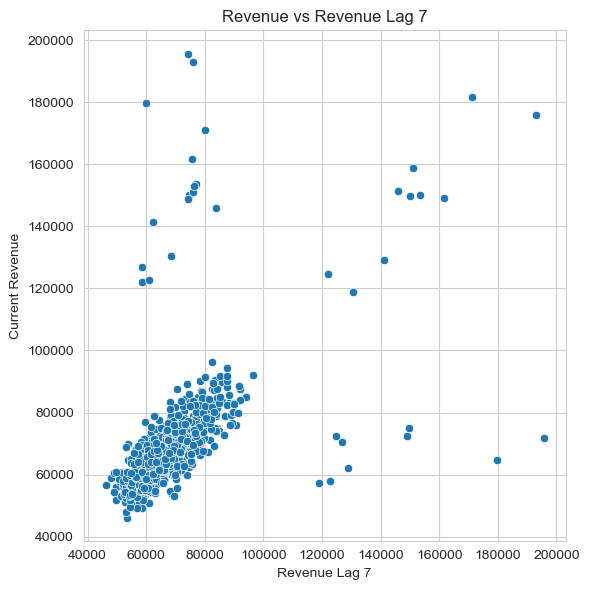

In [34]:
"""
Lag Feature Validation
"""

plt.figure(figsize=(6,6))

sns.scatterplot(
    x=daily_sales["revenue_lag_7"],
    y=daily_sales["daily_revenue"]
)

plt.title("Revenue vs Revenue Lag 7")
plt.xlabel("Revenue Lag 7")
plt.ylabel("Current Revenue")

save_plot("revenue_vs_lag7_scatter.png")

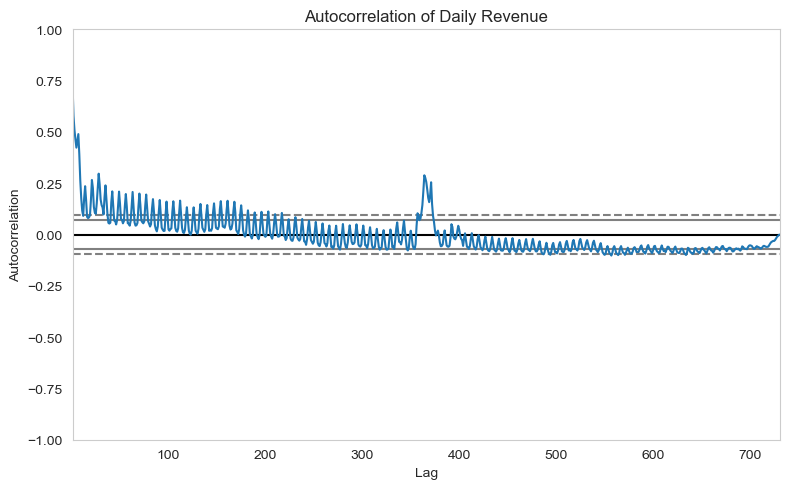

In [35]:
plt.figure(figsize=(8,5))

autocorrelation_plot(daily_sales["daily_revenue"])

plt.title("Autocorrelation of Daily Revenue")

save_plot("revenue_autocorrelation.png")

In [36]:
"""
Remove Missing Values from Lag Features
"""

daily_sales = daily_sales.dropna().reset_index(drop=True)

daily_sales.head()

,order_date,daily_revenue,daily_orders,year,month,day,day_of_week,week_of_year,is_weekend,month_sin,month_cos,weekday_sin,weekday_cos,revenue_lag_1,revenue_lag_7,revenue_lag_14,revenue_lag_30,orders_lag_1,orders_lag_7,orders_lag_14,orders_lag_30
0,2023-01-31,56712.27,516,2023,1,31,1,5,0,0.500000,0.866025,0.781831,0.623490,57112.51,56657.94,46170.18,66253.81,542.0,540.0,490.0,613.0
1,2023-02-01,56107.77,519,2023,2,1,2,5,0,0.866025,0.500000,0.974928,-0.222521,56712.27,49552.93,55155.57,54665.55,516.0,501.0,493.0,504.0
2,2023-02-02,60905.25,527,2023,2,2,3,5,0,0.866025,0.500000,0.433884,-0.900969,56107.77,54137.29,59990.82,59619.06,519.0,511.0,524.0,535.0
3,2023-02-03,50711.02,488,2023,2,3,4,5,0,0.866025,0.500000,-0.433884,-0.900969,60905.25,60941.92,51580.62,51748.44,527.0,575.0,485.0,482.0
4,2023-02-04,60230.44,590,2023,2,4,5,5,1,0.866025,0.500000,-0.974928,-0.222521,50711.02,66172.98,61306.60,49735.05,488.0,592.0,596.0,468.0


## Rolling Window Feature Engineering

Rolling window features compute statistics over a moving window of past observations.

These features help capture short-term trends and smooth fluctuations in the time series.

Examples include:

### Rolling Mean

The average value over a past window of time.

### Rolling Standard Deviation

Measures the variability of the series over a recent period.

These statistics provide useful signals about the recent behavior of the time series.

In this section, I compute rolling window statistics to capture recent trends in revenue and order volume.

In [37]:
"""
Revenue Rolling Mean Features
"""

windows = [7, 14, 30]

for window in windows:
    
    daily_sales[f"revenue_roll_mean_{window}"] = (
        daily_sales["daily_revenue"]
        .rolling(window=window)
        .mean()
    )

daily_sales.head(20)

,order_date,daily_revenue,daily_orders,year,month,day,day_of_week,week_of_year,is_weekend,month_sin,month_cos,weekday_sin,weekday_cos,revenue_lag_1,revenue_lag_7,revenue_lag_14,revenue_lag_30,orders_lag_1,orders_lag_7,orders_lag_14,orders_lag_30,revenue_roll_mean_7,revenue_roll_mean_14,revenue_roll_mean_30
0,2023-01-31,56712.27,516,2023,1,31,1,5,0,0.500000,0.866025,0.781831,0.623490,57112.51,56657.94,46170.18,66253.81,542.0,540.0,490.0,613.0,NaN,NaN,NaN
1,2023-02-01,56107.77,519,2023,2,1,2,5,0,0.866025,0.500000,0.974928,-0.222521,56712.27,49552.93,55155.57,54665.55,516.0,501.0,493.0,504.0,NaN,NaN,NaN
2,2023-02-02,60905.25,527,2023,2,2,3,5,0,0.866025,0.500000,0.433884,-0.900969,56107.77,54137.29,59990.82,59619.06,519.0,511.0,524.0,535.0,NaN,NaN,NaN
3,2023-02-03,50711.02,488,2023,2,3,4,5,0,0.866025,0.500000,-0.433884,-0.900969,60905.25,60941.92,51580.62,51748.44,527.0,575.0,485.0,482.0,NaN,NaN,NaN
4,2023-02-04,60230.44,590,2023,2,4,5,5,1,0.866025,0.500000,-0.974928,-0.222521,50711.02,66172.98,61306.60,49735.05,488.0,592.0,596.0,468.0,NaN,NaN,NaN
5,2023-02-05,62506.82,601,2023,2,5,6,5,1,0.866025,0.500000,-0.781831,0.623490,60230.44,67120.79,66580.91,55661.22,590.0,623.0,634.0,518.0,NaN,NaN,NaN
6,2023-02-06,52980.66,472,2023,2,6,0,6,0,0.866025,0.500000,0.000000,1.000000,62506.82,57112.51,57741.53,73869.22,601.0,542.0,523.0,621.0,57164.890000,NaN,NaN
7,2023-02-07,57324.45,535,2023,2,7,1,6,0,0.866025,0.500000,0.781831,0.623490,52980.66,56712.27,56657.94,58601.95,472.0,516.0,540.0,566.0,57252.344286,NaN,NaN
8,2023-02-08,56281.50,520,2023,2,8,2,6,0,0.866025,0.500000,0.974928,-0.222521,57324.45,56107.77,49552.93,54136.72,535.0,519.0,501.0,475.0,57277.162857,NaN,NaN
9,2023-02-09,54998.67,547,2023,2,9,3,6,0,0.866025,0.500000,0.433884,-0.900969,56281.50,60905.25,54137.29,53332.30,520.0,527.0,511.0,537.0,56433.365714,NaN,NaN


In [38]:
"""
Revenue Rolling Standard Deviation
"""

for window in windows:
    
    daily_sales[f"revenue_roll_std_{window}"] = (
        daily_sales["daily_revenue"]
        .rolling(window=window)
        .std()
    )

daily_sales.head(20)

,order_date,daily_revenue,daily_orders,year,month,day,day_of_week,week_of_year,is_weekend,month_sin,month_cos,weekday_sin,weekday_cos,revenue_lag_1,revenue_lag_7,revenue_lag_14,revenue_lag_30,orders_lag_1,orders_lag_7,orders_lag_14,orders_lag_30,revenue_roll_mean_7,revenue_roll_mean_14,revenue_roll_mean_30,revenue_roll_std_7,revenue_roll_std_14,revenue_roll_std_30
0,2023-01-31,56712.27,516,2023,1,31,1,5,0,0.500000,0.866025,0.781831,0.623490,57112.51,56657.94,46170.18,66253.81,542.0,540.0,490.0,613.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-02-01,56107.77,519,2023,2,1,2,5,0,0.866025,0.500000,0.974928,-0.222521,56712.27,49552.93,55155.57,54665.55,516.0,501.0,493.0,504.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-02-02,60905.25,527,2023,2,2,3,5,0,0.866025,0.500000,0.433884,-0.900969,56107.77,54137.29,59990.82,59619.06,519.0,511.0,524.0,535.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-02-03,50711.02,488,2023,2,3,4,5,0,0.866025,0.500000,-0.433884,-0.900969,60905.25,60941.92,51580.62,51748.44,527.0,575.0,485.0,482.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-02-04,60230.44,590,2023,2,4,5,5,1,0.866025,0.500000,-0.974928,-0.222521,50711.02,66172.98,61306.60,49735.05,488.0,592.0,596.0,468.0,NaN,NaN,NaN,NaN,NaN,NaN
5,2023-02-05,62506.82,601,2023,2,5,6,5,1,0.866025,0.500000,-0.781831,0.623490,60230.44,67120.79,66580.91,55661.22,590.0,623.0,634.0,518.0,NaN,NaN,NaN,NaN,NaN,NaN
6,2023-02-06,52980.66,472,2023,2,6,0,6,0,0.866025,0.500000,0.000000,1.000000,62506.82,57112.51,57741.53,73869.22,601.0,542.0,523.0,621.0,57164.890000,NaN,NaN,4328.330935,NaN,NaN
7,2023-02-07,57324.45,535,2023,2,7,1,6,0,0.866025,0.500000,0.781831,0.623490,52980.66,56712.27,56657.94,58601.95,472.0,516.0,540.0,566.0,57252.344286,NaN,NaN,4323.843754,NaN,NaN
8,2023-02-08,56281.50,520,2023,2,8,2,6,0,0.866025,0.500000,0.974928,-0.222521,57324.45,56107.77,49552.93,54136.72,535.0,519.0,501.0,475.0,57277.162857,NaN,NaN,4316.671663,NaN,NaN
9,2023-02-09,54998.67,547,2023,2,9,3,6,0,0.866025,0.500000,0.433884,-0.900969,56281.50,60905.25,54137.29,53332.30,520.0,527.0,511.0,537.0,56433.365714,NaN,NaN,4058.868551,NaN,NaN


In [39]:
"""
Orders Rolling Mean Features
"""

for window in windows:
    
    daily_sales[f"orders_roll_mean_{window}"] = (
        daily_sales["daily_orders"]
        .rolling(window=window)
        .mean()
    )

daily_sales.head(20)

,order_date,daily_revenue,daily_orders,year,month,day,day_of_week,week_of_year,is_weekend,month_sin,month_cos,weekday_sin,weekday_cos,revenue_lag_1,revenue_lag_7,revenue_lag_14,revenue_lag_30,orders_lag_1,orders_lag_7,orders_lag_14,orders_lag_30,revenue_roll_mean_7,revenue_roll_mean_14,revenue_roll_mean_30,revenue_roll_std_7,revenue_roll_std_14,revenue_roll_std_30,orders_roll_mean_7,orders_roll_mean_14,orders_roll_mean_30
0,2023-01-31,56712.27,516,2023,1,31,1,5,0,0.500000,0.866025,0.781831,0.623490,57112.51,56657.94,46170.18,66253.81,542.0,540.0,490.0,613.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-02-01,56107.77,519,2023,2,1,2,5,0,0.866025,0.500000,0.974928,-0.222521,56712.27,49552.93,55155.57,54665.55,516.0,501.0,493.0,504.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-02-02,60905.25,527,2023,2,2,3,5,0,0.866025,0.500000,0.433884,-0.900969,56107.77,54137.29,59990.82,59619.06,519.0,511.0,524.0,535.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-02-03,50711.02,488,2023,2,3,4,5,0,0.866025,0.500000,-0.433884,-0.900969,60905.25,60941.92,51580.62,51748.44,527.0,575.0,485.0,482.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-02-04,60230.44,590,2023,2,4,5,5,1,0.866025,0.500000,-0.974928,-0.222521,50711.02,66172.98,61306.60,49735.05,488.0,592.0,596.0,468.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2023-02-05,62506.82,601,2023,2,5,6,5,1,0.866025,0.500000,-0.781831,0.623490,60230.44,67120.79,66580.91,55661.22,590.0,623.0,634.0,518.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2023-02-06,52980.66,472,2023,2,6,0,6,0,0.866025,0.500000,0.000000,1.000000,62506.82,57112.51,57741.53,73869.22,601.0,542.0,523.0,621.0,57164.890000,NaN,NaN,4328.330935,NaN,NaN,530.428571,NaN,NaN
7,2023-02-07,57324.45,535,2023,2,7,1,6,0,0.866025,0.500000,0.781831,0.623490,52980.66,56712.27,56657.94,58601.95,472.0,516.0,540.0,566.0,57252.344286,NaN,NaN,4323.843754,NaN,NaN,533.142857,NaN,NaN
8,2023-02-08,56281.50,520,2023,2,8,2,6,0,0.866025,0.500000,0.974928,-0.222521,57324.45,56107.77,49552.93,54136.72,535.0,519.0,501.0,475.0,57277.162857,NaN,NaN,4316.671663,NaN,NaN,533.285714,NaN,NaN
9,2023-02-09,54998.67,547,2023,2,9,3,6,0,0.866025,0.500000,0.433884,-0.900969,56281.50,60905.25,54137.29,53332.30,520.0,527.0,511.0,537.0,56433.365714,NaN,NaN,4058.868551,NaN,NaN,536.142857,NaN,NaN


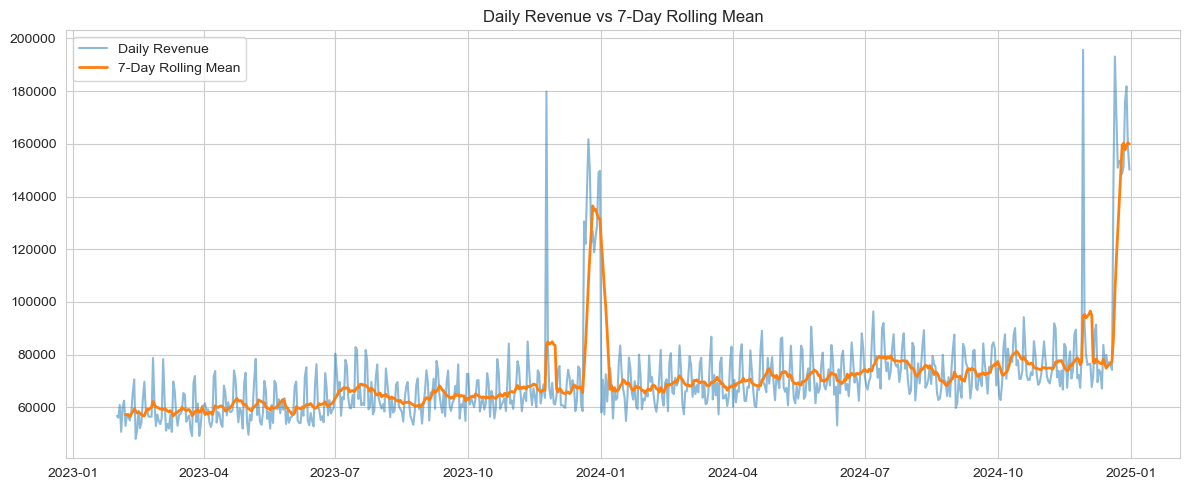

In [40]:
plt.figure(figsize=(12,5))

plt.plot(
    daily_sales["order_date"],
    daily_sales["daily_revenue"],
    label="Daily Revenue",
    alpha=0.5
)

plt.plot(
    daily_sales["order_date"],
    daily_sales["revenue_roll_mean_7"],
    label="7-Day Rolling Mean",
    linewidth=2
)

plt.legend()

plt.title("Daily Revenue vs 7-Day Rolling Mean")

save_plot("revenue_rolling_mean_validation.png")

In [41]:
"""
Remove Missing Values from Rolling Features
"""

daily_sales = daily_sales.dropna().reset_index(drop=True)

daily_sales.head()

,order_date,daily_revenue,daily_orders,year,month,day,day_of_week,week_of_year,is_weekend,month_sin,month_cos,weekday_sin,weekday_cos,revenue_lag_1,revenue_lag_7,revenue_lag_14,revenue_lag_30,orders_lag_1,orders_lag_7,orders_lag_14,orders_lag_30,revenue_roll_mean_7,revenue_roll_mean_14,revenue_roll_mean_30,revenue_roll_std_7,revenue_roll_std_14,revenue_roll_std_30,orders_roll_mean_7,orders_roll_mean_14,orders_roll_mean_30
0,2023-03-01,54756.68,518,2023,3,1,2,9,0,1.0,6.123234e-17,0.974928,-0.222521,57302.94,56437.35,58696.88,57112.51,501.0,522.0,514.0,542.0,59744.527143,59405.285714,58424.730000,8793.149490,7205.569421,6398.566419,556.714286,549.000000,544.300000
1,2023-03-02,53631.11,538,2023,3,2,3,9,0,1.0,6.123234e-17,0.433884,-0.900969,54756.68,56428.47,52092.77,56712.27,518.0,523.0,517.0,516.0,59344.904286,59515.167143,58322.024667,9029.365176,7096.381434,6451.510746,558.857143,550.500000,545.033333
2,2023-03-03,55755.00,543,2023,3,3,4,9,0,1.0,6.123234e-17,-0.433884,-0.900969,53631.11,56456.45,54199.08,56107.77,538.0,538.0,488.0,519.0,59244.697143,59626.304286,58310.265667,9070.561975,7018.477464,6456.005704,559.571429,554.428571,545.833333
3,2023-03-04,78290.06,666,2023,3,4,5,9,1,1.0,6.123234e-17,-0.974928,-0.222521,55755.00,78741.79,63134.67,60905.25,543.0,656.0,601.0,527.0,59180.164286,60708.832143,58889.759333,8908.896605,8593.326357,7407.135727,561.000000,559.071429,550.466667
4,2023-03-05,63179.98,593,2023,3,5,6,9,1,1.0,6.123234e-17,-0.781831,0.623490,78290.06,61624.68,69724.16,50711.02,666.0,651.0,619.0,488.0,59402.350000,60241.390714,59305.391333,8998.962306,8235.755848,7281.142029,552.714286,557.214286,553.966667


## Feature Correlation Analysis

Before training forecasting models, I analyze correlations between features.

Correlation analysis helps identify:

- highly related variables
- redundant features
- potential multicollinearity issues

Understanding feature relationships can improve model interpretability and guide feature selection.

In this section, I compute and visualize the correlation matrix for the forecasting feature set.

In [42]:
"""
Select Forecasting Features
"""

forecast_features = daily_sales.drop(
    columns=["order_date"]
)

forecast_features.head()

,daily_revenue,daily_orders,year,month,day,day_of_week,week_of_year,is_weekend,month_sin,month_cos,weekday_sin,weekday_cos,revenue_lag_1,revenue_lag_7,revenue_lag_14,revenue_lag_30,orders_lag_1,orders_lag_7,orders_lag_14,orders_lag_30,revenue_roll_mean_7,revenue_roll_mean_14,revenue_roll_mean_30,revenue_roll_std_7,revenue_roll_std_14,revenue_roll_std_30,orders_roll_mean_7,orders_roll_mean_14,orders_roll_mean_30
0,54756.68,518,2023,3,1,2,9,0,1.0,6.123234e-17,0.974928,-0.222521,57302.94,56437.35,58696.88,57112.51,501.0,522.0,514.0,542.0,59744.527143,59405.285714,58424.730000,8793.149490,7205.569421,6398.566419,556.714286,549.000000,544.300000
1,53631.11,538,2023,3,2,3,9,0,1.0,6.123234e-17,0.433884,-0.900969,54756.68,56428.47,52092.77,56712.27,518.0,523.0,517.0,516.0,59344.904286,59515.167143,58322.024667,9029.365176,7096.381434,6451.510746,558.857143,550.500000,545.033333
2,55755.00,543,2023,3,3,4,9,0,1.0,6.123234e-17,-0.433884,-0.900969,53631.11,56456.45,54199.08,56107.77,538.0,538.0,488.0,519.0,59244.697143,59626.304286,58310.265667,9070.561975,7018.477464,6456.005704,559.571429,554.428571,545.833333
3,78290.06,666,2023,3,4,5,9,1,1.0,6.123234e-17,-0.974928,-0.222521,55755.00,78741.79,63134.67,60905.25,543.0,656.0,601.0,527.0,59180.164286,60708.832143,58889.759333,8908.896605,8593.326357,7407.135727,561.000000,559.071429,550.466667
4,63179.98,593,2023,3,5,6,9,1,1.0,6.123234e-17,-0.781831,0.623490,78290.06,61624.68,69724.16,50711.02,666.0,651.0,619.0,488.0,59402.350000,60241.390714,59305.391333,8998.962306,8235.755848,7281.142029,552.714286,557.214286,553.966667


In [43]:
"""
Compute Correlation Matrix
"""

correlation_matrix = forecast_features.corr()

correlation_matrix.head()

,daily_revenue,daily_orders,year,month,day,day_of_week,week_of_year,is_weekend,month_sin,month_cos,weekday_sin,weekday_cos,revenue_lag_1,revenue_lag_7,revenue_lag_14,revenue_lag_30,orders_lag_1,orders_lag_7,orders_lag_14,orders_lag_30,revenue_roll_mean_7,revenue_roll_mean_14,revenue_roll_mean_30,revenue_roll_std_7,revenue_roll_std_14,revenue_roll_std_30,orders_roll_mean_7,orders_roll_mean_14,orders_roll_mean_30
daily_revenue,1.000000,0.965951,0.249803,0.361978,0.185705,0.279947,0.325867,0.329843,-0.094752,0.310039,-0.290637,0.034288,0.736320,0.544104,0.283904,0.216612,0.735294,0.506684,0.216647,0.171309,0.782387,0.676333,0.594274,0.492607,0.590446,0.535474,0.754944,0.634896,0.536959
daily_orders,0.965951,1.000000,0.184795,0.350328,0.201927,0.217245,0.316003,0.251442,-0.104594,0.242927,-0.226575,0.024452,0.740402,0.521620,0.224070,0.199994,0.772570,0.514922,0.181819,0.157142,0.791383,0.673490,0.566565,0.500800,0.604280,0.541759,0.804355,0.673625,0.546836
year,0.249803,0.184795,1.000000,-0.151651,-0.002658,-0.007470,-0.150337,-0.003780,0.094346,0.095605,0.003304,0.006861,0.261067,0.317964,0.397426,0.400357,0.196504,0.255093,0.333216,0.335529,0.353326,0.467425,0.642782,0.070284,0.093686,0.147629,0.261634,0.359407,0.524257
month,0.361978,0.350328,-0.151651,1.000000,0.004138,0.008499,0.977736,0.010315,-0.744815,0.392443,-0.010510,0.004051,0.335704,0.199557,0.036174,0.037250,0.321917,0.167233,-0.012731,-0.002686,0.367029,0.300697,0.215893,0.191306,0.249009,0.121643,0.330897,0.250151,0.149047
day,0.185705,0.201927,-0.002658,0.004138,1.000000,0.002361,0.074632,-0.001653,-0.003736,-0.001151,0.008452,-0.006792,0.170441,0.043261,-0.059505,0.121684,0.184242,0.031589,-0.069524,0.133508,0.170743,0.087952,0.076209,0.052808,0.033192,0.073020,0.166273,0.079462,0.074190


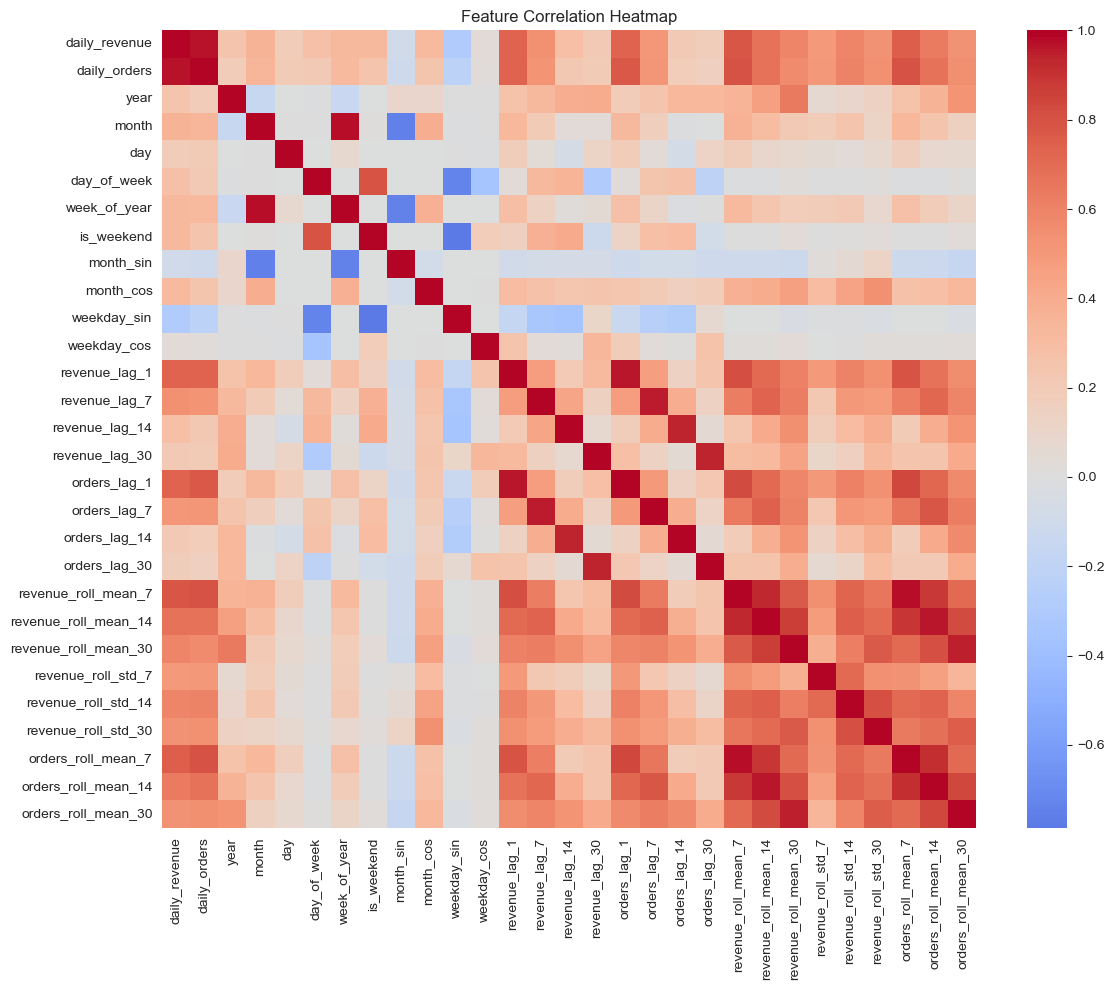

In [44]:
plt.figure(figsize=(12,10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

save_plot("forecast_feature_correlation_heatmap.png")

## Feature Store

A feature store is a centralized repository that stores engineered features for machine learning models.

In this project, I create two feature datasets.

### Customer Features

Used for customer segmentation and marketing analytics.

### Time-Series Features

Used for sales forecasting models.

Separating these datasets improves pipeline organization and reflects best practices used in production machine learning systems.

In [45]:
"""
Create Feature Datasets
"""

customer_features = customers.merge(
    rfm,
    on="customer_id",
    how="left"
)

timeseries_features = daily_sales.copy()

customer_features.head()

,customer_id,signup_date,age,income,country,loyalty_member,website_visits,app_usage,discount_usage,engagement_score,purchase_propensity,total_orders,total_spent,average_order_value,days_since_last_purchase,customer_tenure_days_x,engagement_index,recency_days,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_score,customer_segment,avg_spend_per_order,customer_tenure_days_y,purchase_rate
0,6173,2023-01-01,38,70953,Portugal,True,8,4,False,0.206216,0.369702,47.0,4547.73,96.760213,7.0,730,4.461865,7.0,47.0,4547.73,2,3,3,233,At Risk,96.760213,730.0,0.064295
1,7128,2023-01-03,21,42602,Spain,True,11,4,True,0.438138,0.493732,68.0,5440.13,80.001912,10.0,728,5.731441,10.0,68.0,5440.13,2,4,3,243,At Risk,80.001912,728.0,0.093278
2,4220,2023-01-03,40,30478,France,False,12,2,True,0.546699,0.320223,40.0,3978.12,99.453000,4.0,728,5.564010,4.0,40.0,3978.12,3,2,2,322,At Risk,99.453000,728.0,0.054870
3,1120,2023-01-04,52,22415,Portugal,True,13,1,True,0.562599,0.575448,118.0,11282.80,95.616949,2.0,727,5.668780,2.0,118.0,11282.80,4,5,5,455,At Risk,95.616949,727.0,0.162088
4,2020,2023-01-05,51,39682,Italy,False,9,4,False,0.254583,0.136320,17.0,2259.21,132.894706,1.0,726,4.876375,1.0,17.0,2259.21,5,1,1,511,At Risk,132.894706,726.0,0.023384


In [46]:
"""
Export Feature Store
"""

customer_features.to_csv(
    f"{DATA_PATH}/model_features_customers.csv",
    index=False
)

timeseries_features.to_csv(
    f"{DATA_PATH}/model_features_timeseries.csv",
    index=False
)

print("Feature store exported successfully.")

Feature store exported successfully.
